# CNN with BatchNorm, GAP, Augmentation, and Weighted Loss

- Replaces the large flatten-based classifier with global average pooling
- Uses stronger training augmentation
- Trains longer with early stopping on validation F2

**Objective**
Test whether a smaller classifier head plus stronger augmentation improves generalization and reduces the early plateau seen in the previous weighted BatchNorm CNN experiment.


In [11]:
import sys
import os
import copy

sys.path.append(os.path.abspath("../.."))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.cnn_batchnorm_gap import BatchNormGAPCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


In [12]:
use_mps = True

print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")


MPS available: True
Using device: mps


In [13]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()
num_nevus = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight)


pos_weight: tensor([6.0244], device='mps:0')


In [14]:
model = BatchNormGAPCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

model_save_path = os.path.abspath("../../models/cnn_batchnorm_gap_augmented_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 50
early_stopping_patience = 8

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None


In [15]:
for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics["f2"])

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f"Saved best model at epoch {best_epoch}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print(f"Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/50] | LR: 0.001000 | Train Loss: 1.0319, Train Acc: 0.5729, Train F2: 0.5235 | Val Loss: 1.0071, Val Acc: 0.6462, Val F2: 0.5560
Saved best model at epoch 1


Epoch [2/50] | LR: 0.001000 | Train Loss: 0.9746, Train Acc: 0.5903, Train F2: 0.5601 | Val Loss: 0.9580, Val Acc: 0.7434, Val F2: 0.5905
Saved best model at epoch 2


Epoch [3/50] | LR: 0.001000 | Train Loss: 0.9406, Train Acc: 0.6210, Train F2: 0.5798 | Val Loss: 0.8925, Val Acc: 0.7664, Val F2: 0.6024
Saved best model at epoch 3


Epoch [4/50] | LR: 0.001000 | Train Loss: 0.9284, Train Acc: 0.6336, Train F2: 0.5726 | Val Loss: 1.1514, Val Acc: 0.8142, Val F2: 0.4871


Epoch [5/50] | LR: 0.001000 | Train Loss: 0.9149, Train Acc: 0.6442, Train F2: 0.5848 | Val Loss: 1.1402, Val Acc: 0.6974, Val F2: 0.5403


...

Epoch [26/50] | LR: 0.000125 | Train Loss: 0.7068, Train Acc: 0.7654, Train F2: 0.6819 | Val Loss: 0.7281, Val Acc: 0.7400, Val F2: 0.6879


Epoch [27/50] | LR: 0.000063 | Train Loss: 0.7168, Train Acc: 0.7582, Train F2: 0.6758 | Val Loss: 0.7315, Val Acc: 0.7246, Val F2: 0.6802


Epoch [28/50] | LR: 0.000063 | Train Loss: 0.7105, Train Acc: 0.7569, Train F2: 0.6742 | Val Loss: 0.7182, Val Acc: 0.7528, Val F2: 0.6874


Epoch [29/50] | LR: 0.000063 | Train Loss: 0.6931, Train Acc: 0.7628, Train F2: 0.6704 | Val Loss: 0.7270, Val Acc: 0.7255, Val F2: 0.6808


Epoch [30/50] | LR: 0.000063 | Train Loss: 0.6999, Train Acc: 0.7621, Train F2: 0.6706 | Val Loss: 0.7257, Val Acc: 0.7400, Val F2: 0.6847
Early stopping triggered at epoch 30
Best validation F2: 0.6967 at epoch 22


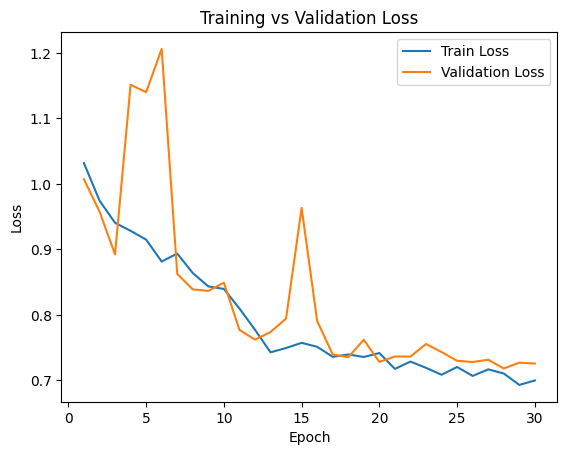

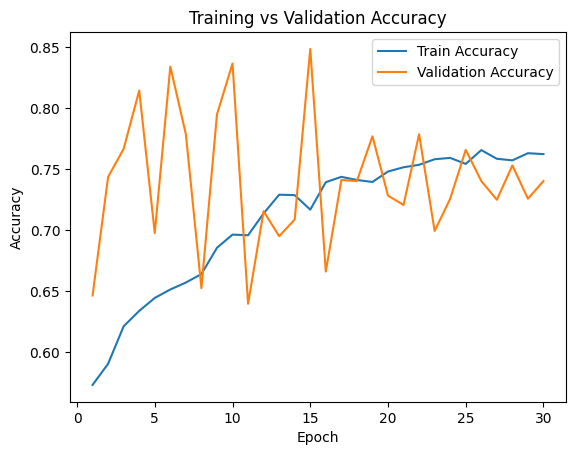

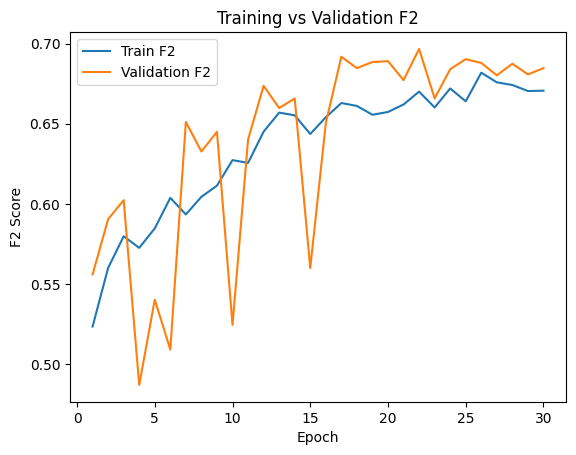

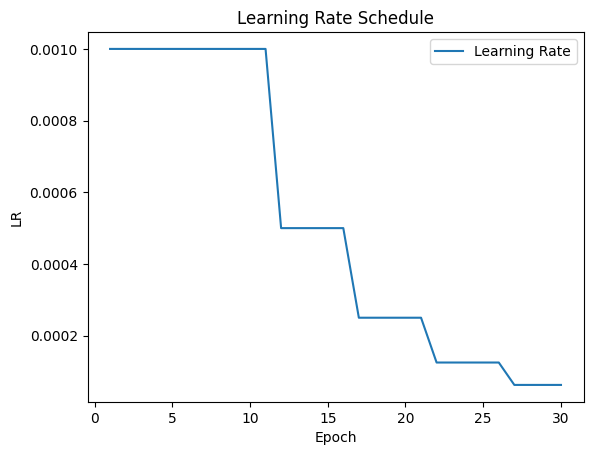

In [20]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")
plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, learning_rates, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()


This section sweeps thresholds on the validation set and keeps the threshold with the best F2 score.


In [21]:
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)
best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds, zero_division=0):.4f} | "
        f"Recall={recall_score(val_labels, preds, zero_division=0):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"Best threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.5813 | Precision=0.2221 | Recall=0.9760 | Balanced Acc=0.7042
Threshold=0.10 | F2=0.6069 | Precision=0.2415 | Recall=0.9760 | Balanced Acc=0.7336
Threshold=0.15 | F2=0.6207 | Precision=0.2543 | Recall=0.9701 | Balanced Acc=0.7489
Threshold=0.20 | F2=0.6216 | Precision=0.2568 | Recall=0.9641 | Balanced Acc=0.7504
Threshold=0.25 | F2=0.6309 | Precision=0.2648 | Recall=0.9641 | Balanced Acc=0.7599
Threshold=0.30 | F2=0.6425 | Precision=0.2752 | Recall=0.9641 | Balanced Acc=0.7713
Threshold=0.35 | F2=0.6525 | Precision=0.2867 | Recall=0.9581 | Balanced Acc=0.7812
Threshold=0.40 | F2=0.6727 | Precision=0.3146 | Recall=0.9401 | Balanced Acc=0.8001
Threshold=0.45 | F2=0.6936 | Precision=0.3517 | Recall=0.9162 | Balanced Acc=0.8179
Threshold=0.50 | F2=0.6967 | Precision=0.3798 | Recall=0.8802 | Balanced Acc=0.8208
Threshold=0.55 | F2=0.6931 | Precision=0.4094 | Recall=0.8383 | Balanced Acc=0.8188
Threshold=0.60 | F2=0.6725 | Precision=0.4281 | Recall=0.7844 | Balanced Acc

Confusion Matrix:
[[755 251]
 [ 22 145]]

              precision    recall  f1-score   support

           0     0.9717    0.7505    0.8469      1006
           1     0.3662    0.8683    0.5151       167

    accuracy                         0.7673      1173
   macro avg     0.6689    0.8094    0.6810      1173
weighted avg     0.8855    0.7673    0.7997      1173



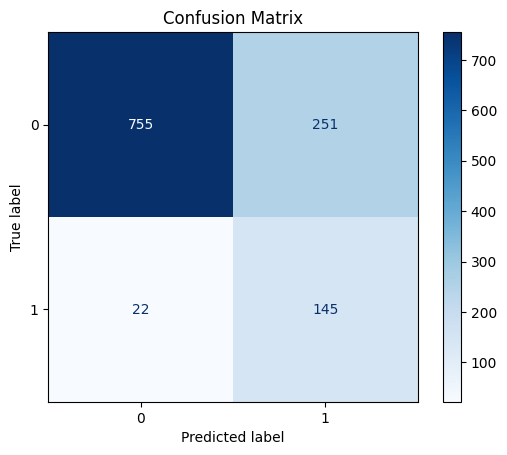

In [22]:
model = BatchNormGAPCNN().to(device)
model.load_state_dict(torch.load(model_save_path, map_location="cpu"))
model.to(device)
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## Summary

05.cnn_batchnorm_gap_augmented_weighted.ipynb is an improvement overall, to better-balanced melanoma detection.

Compared with 03.cnn_batchnorm_weighted.ipynb:

- Best validation F2 improved from about 0.6892 vs the old run’s threshold-swept validation F2 around 0.6699.
- Test accuracy improved from about 0.7178 to 0.7639.
- Positive-class precision improved from about 0.3263 to 0.3575.
- Positive-class recall dropped from about 0.9222 to 0.8263.

So overall, this is better, with a more balanced precision/recall tradeoff, but slightly worse recall than before. 

If the priority is to avoid missing melanoma at all costs, the old run is still more aggressive. If the goal is a stronger overall classifier with fewer false positives, this version is better.

What the notebook is doing:

- It loads the train/val/test splits and the HAM10000 images.
- It applies stronger training augmentation while keeping validation/test transforms clean.
- It computes pos_weight for BCEWithLogitsLoss so melanoma gets more weight due to class imbalance.
- It trains a compact CNN, BatchNormGAPCNN, from cnn_batchnorm_gap.py.
- It tracks train/val loss, accuracy, and F2 at every epoch.
- It uses ReduceLROnPlateau to reduce the learning rate when validation F2 stops improving.
- It applies early stopping once validation F2 plateaus.
- After training, it sweeps classification thresholds on the validation set and selects the one with the best F2.
- It evaluates on the test set using that threshold and prints the confusion matrix and classification report.

What changed:

- Global average pooling:
In the old CNN, the flatten layer fed into a very large fully connected head. The new model reduces this significantly, which lowers over-parameterization and improves generalization. The model is now about 110k parameters instead of about 25.8M.

- Stronger augmentation:
This helps prevent memorization of superficial patterns and encourages learning more robust lesion features.

- Weighted BCE loss:
Since the dataset is imbalanced, this prevents the model from biasing too heavily toward the majority class.

- LR scheduler:
This turned out to be useful. Performance improved again after the learning rate dropped from 0.001 to 0.0005 around epoch 13, suggesting the scheduler helped push past an early plateau.

- Early stopping:
Training stopped at epoch 25, with the best validation F2 at epoch 17. Beyond that point, further training did not provide meaningful gains.

- Threshold sweep:
For imbalanced binary classification, 0.5 is not always optimal. In this run, 0.50 ended up being the best threshold on validation, which suggests the outputs are better calibrated than before.

What the training curve says:

- Learning is steady instead of plateauing early.
- Validation is still somewhat noisy, but less “stuck” compared to before.
- The strongest improvement phase happens after the first learning rate reduction.
- Train and validation F2 remain reasonably close, so there is no clear sign of severe overfitting.

Collected 9 correct predictions and 9 wrong predictions.


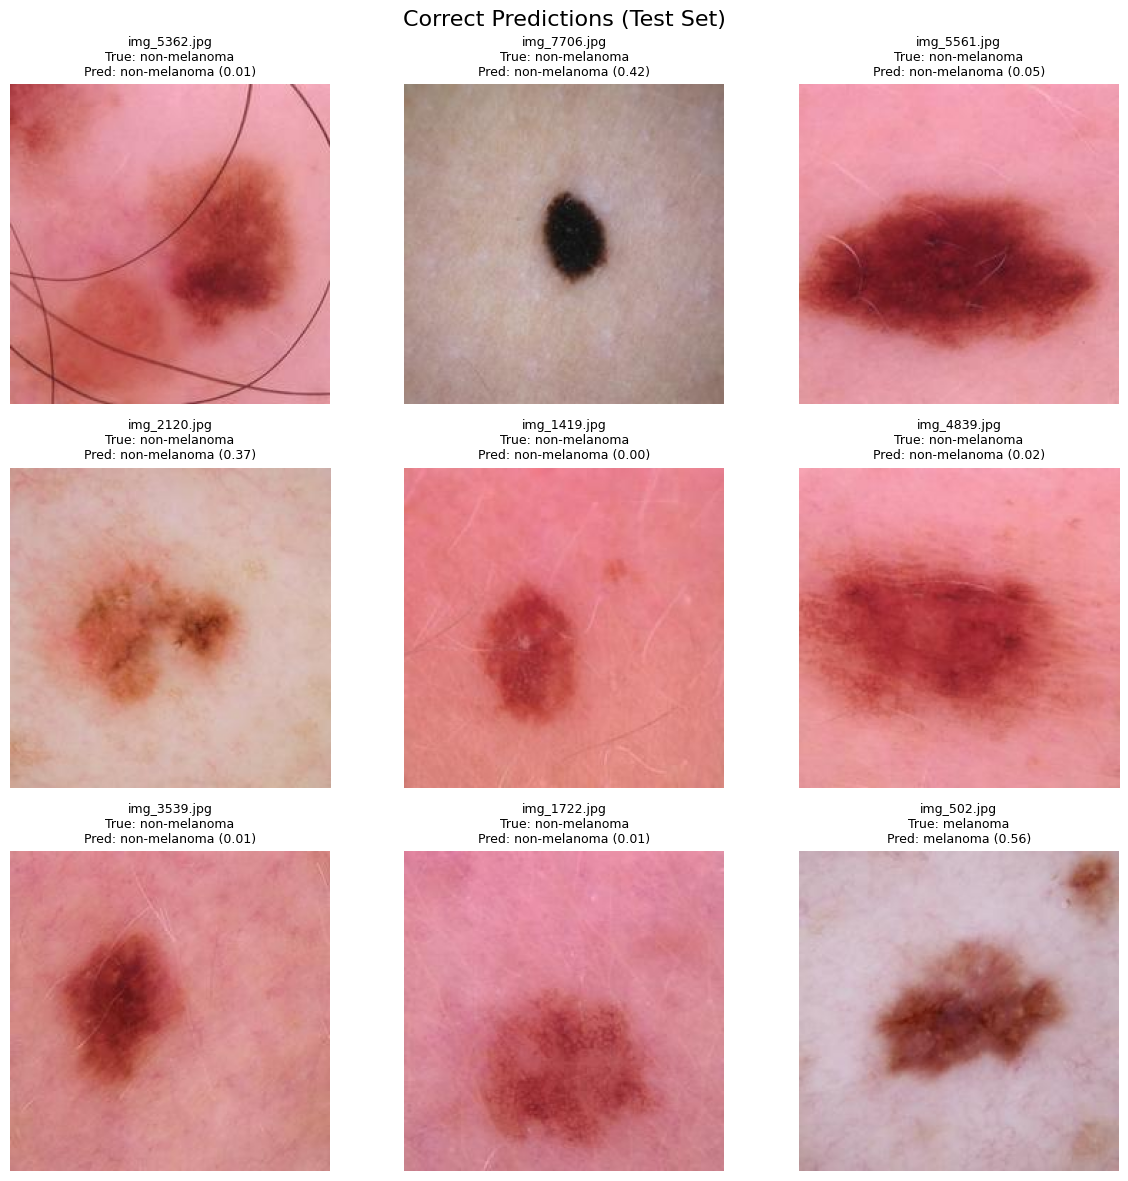

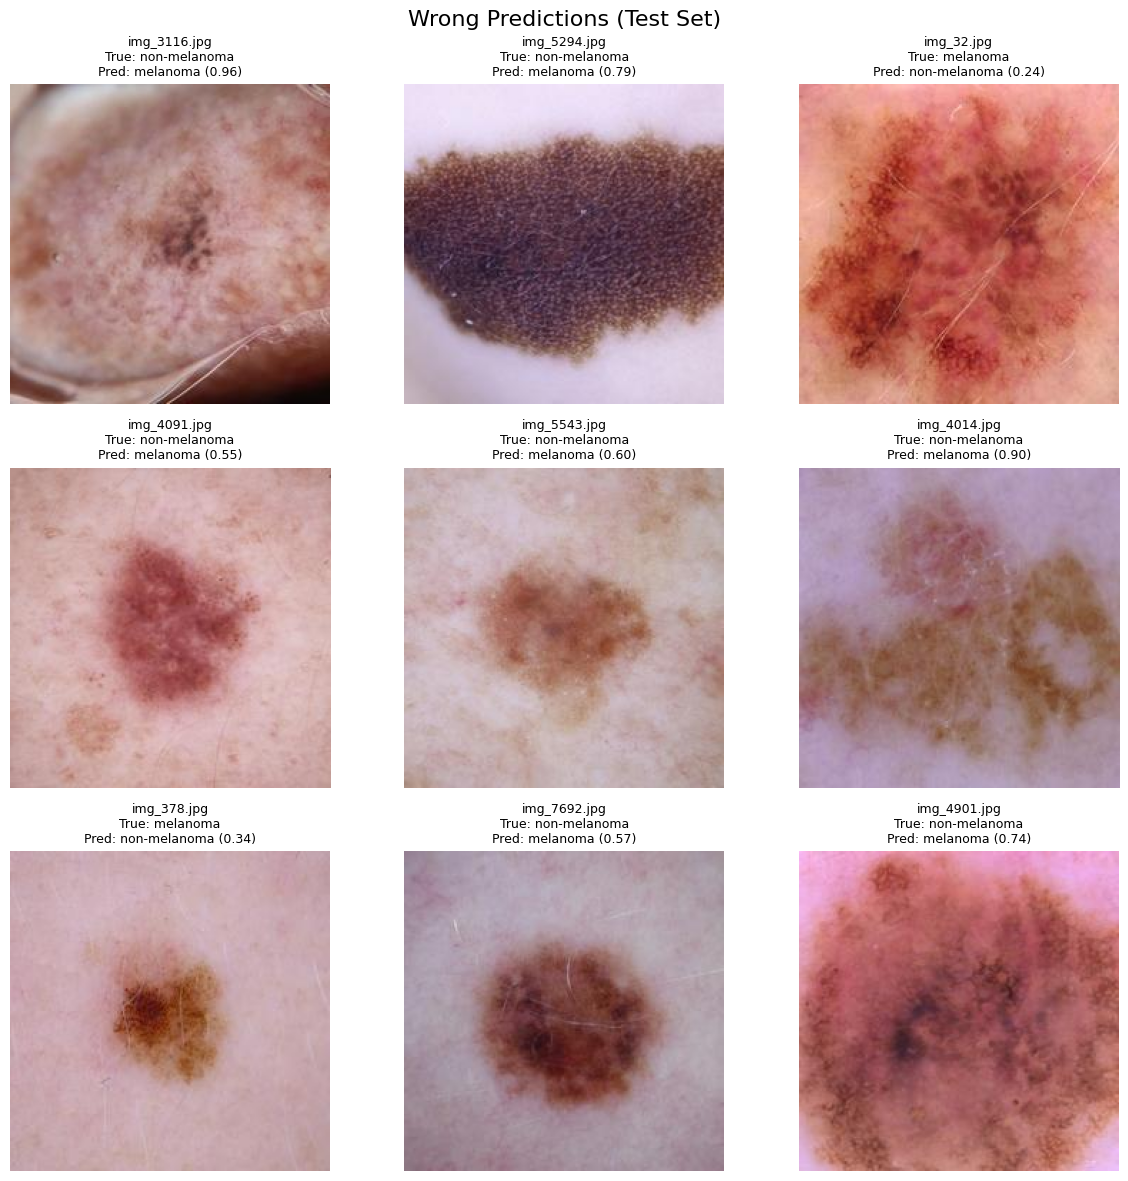

In [24]:
label_names = {0: "non-melanoma", 1: "melanoma"}
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu() * imagenet_std + imagenet_mean
    image = image.permute(1, 2, 0).numpy()
    return np.clip(image, 0, 1)

correct_examples = []
wrong_examples = []
global_idx = 0

test_metadata = test_loader.dataset.data.reset_index(drop=True)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1).cpu()
        preds = (probs >= threshold).long()

        for i in range(len(labels)):
            example = {
                "image": images[i],
                "true_label": int(labels[i].item()),
                "pred_label": int(preds[i].item()),
                "probability": float(probs[i].item()),
                "image_id": test_metadata.iloc[global_idx]["image_id"],
            }

            if example["true_label"] == example["pred_label"]:
                if len(correct_examples) < 9:
                    correct_examples.append(example)
            else:
                if len(wrong_examples) < 9:
                    wrong_examples.append(example)

            global_idx += 1

        if len(correct_examples) >= 9 and len(wrong_examples) >= 9:
            break


def plot_examples(examples, title):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for ax, example in zip(axes, examples):
        ax.imshow(denormalize_image(example["image"]))
        ax.set_title(
            f"{example['image_id']}\n"
            f"True: {label_names[example['true_label']]}\n"
            f"Pred: {label_names[example['pred_label']]} ({example['probability']:.2f})",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print(f"Collected {len(correct_examples)} correct predictions and {len(wrong_examples)} wrong predictions.")
plot_examples(correct_examples, "Correct Predictions (Test Set)")
plot_examples(wrong_examples, "Wrong Predictions (Test Set)")
